# HW3 — `torch.compile` & CUDA Graphs

**Lecture mapping:** L2 §03 (compilation, CUDA graphs) · L1 §07 (profiling)

At batch size 1, a decode step is hundreds of tiny kernels, each finishing faster
than the CPU can launch the next — so generation speed is set by launch overhead,
not FLOPs or bandwidth. You'll measure that overhead and remove it two ways:

1. **Part 1** — measure per-launch overhead and find the tensor size below which a
   kernel is effectively free (launch-bound).
2. **Part 2** — `torch.compile`: what graph breaks are, how to find them with
   `torch._dynamo.explain`, and how to rewrite a decode step to compile as one
   graph (`fullgraph=True`).
3. **Part 3** — capture a decode step into a CUDA graph by hand with
   `torch.cuda.CUDAGraph` (static buffers, side-stream warmup, replay) — what
   `torch.compile(mode="reduce-overhead")` automates.

Parts 1–2 run anywhere; Part 3 and the final benchmark need a GPU.

## What you implement

| Part | Function |
|------|----------|
| 1 | `sweep_elementwise_times` + `estimate_launch_overhead_us` |
| 2 | `fixed_decode_step` — same math as the broken step, zero graph breaks |
| 3 | `make_graphed_callable` — manual CUDA-graph capture + replay |
| 4 | Writeup Q1–Q3 |

## Cell types

- **DO NOT EDIT** — fixed harness.
- **YOUR IMPLEMENTATION** — replace `raise NotImplementedError`.
- **SELF-CHECK** — asserts that must pass.
- **WRITEUP** — answer in the markdown cell.

Run top-to-bottom on the GPU. Submit the executed notebook plus the files under
`results/`.

## Setup (DO NOT EDIT)

In [1]:
# DO NOT EDIT — device + a known-good timer.
import contextlib, io, math, os, time

import torch
from torch import _dynamo as dynamo

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RESULTS_DIR = os.path.join("results", "hw3")
os.makedirs(RESULTS_DIR, exist_ok=True)

torch.set_grad_enabled(False)   # inference-only homework

print(f"torch {torch.__version__}  device={DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))


def bench(fn, n_warmup: int = 10, n_iters: int = 100) -> float:
    """Average seconds per call — CUDA-event timing on GPU, perf_counter on CPU.
    (This is the timer you built yourself in HW1.)"""
    for _ in range(n_warmup):
        fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(n_iters):
            fn()
        end.record()
        torch.cuda.synchronize()
        return start.elapsed_time(end) / 1e3 / n_iters
    t0 = time.perf_counter()
    for _ in range(n_iters):
        fn()
    return (time.perf_counter() - t0) / n_iters

torch 2.11.0+cu128  device=cuda (NVIDIA GeForce RTX 5090 Laptop GPU)


## Part 1 — cost of one kernel launch

A CUDA kernel launch costs the CPU a few microseconds (driver call, queueing)
regardless of how much work the kernel does. For a tiny tensor the GPU finishes
almost instantly, so the wall time is nearly pure launch overhead; only past some
size does the actual work dominate. Sweep one elementwise op across sizes and
find that knee.

In [2]:
# TODO-CELL: sweep_elementwise_times
# YOUR IMPLEMENTATION
def sweep_elementwise_times(sizes: list) -> list:
    """Time ONE out-of-place elementwise op (x + 1.0) over an n-element fp32
    tensor for each n in `sizes`, using the SAME op everywhere. Returns
    seconds-per-call in the same order."""
    times = []
    for n in sizes:
        x = torch.ones(n, device=DEVICE, dtype=torch.float32)
        # bind x as a default arg so each lambda times its own tensor
        times.append(bench(lambda x=x: x + 1.0))
    return times


def estimate_launch_overhead_us(sizes: list, times: list) -> float:
    """Per-launch overhead (µs): average seconds-per-call over the clearly
    launch-bound sizes (n <= 2**12), where the GPU finishes faster than the CPU
    can launch, so wall time is essentially fixed launch cost. Convert to µs."""
    launch_bound = [t for n, t in zip(sizes, times) if n <= 2 ** 12]
    if not launch_bound:                      # safety: fall back to the smallest
        launch_bound = [min(times)]
    avg_seconds = sum(launch_bound) / len(launch_bound)
    return avg_seconds * 1e6

n =          1      21.53 us/call
n =          4      19.37 us/call
n =         16      21.35 us/call
n =         64      17.45 us/call
n =        256      19.11 us/call
n =      1,024      18.71 us/call
n =      4,096      17.77 us/call
n =     16,384      17.92 us/call
n =     65,536      21.69 us/call
n =    262,144      19.16 us/call
n =  1,048,576      20.11 us/call
n =  4,194,304      20.30 us/call
n = 16,777,216     257.77 us/call

estimated per-launch overhead = 19.33 us


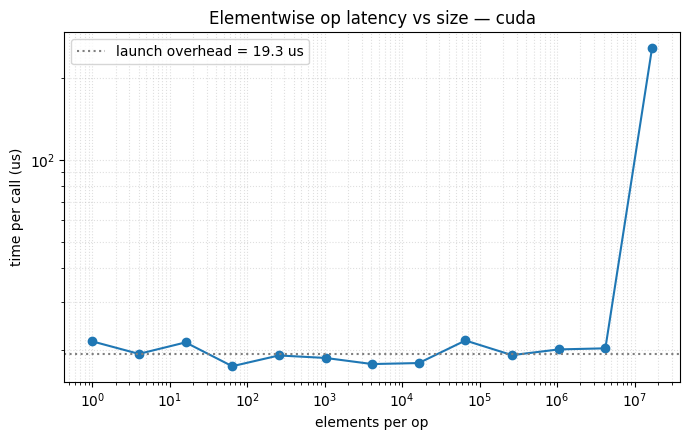

In [3]:
# DO NOT EDIT — run the sweep + plot.
SIZES = [2 ** k for k in range(0, 25, 2)]
times = sweep_elementwise_times(SIZES)
assert len(times) == len(SIZES), "one measurement per size"
overhead_us = estimate_launch_overhead_us(SIZES, times)

for n, t in zip(SIZES, times):
    print(f"n = {n:>10,}   {t * 1e6:8.2f} us/call")
print(f"\nestimated per-launch overhead = {overhead_us:.2f} us")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(SIZES, [t * 1e6 for t in times], "o-")
ax.axhline(overhead_us, ls=":", c="gray",
           label=f"launch overhead = {overhead_us:.1f} us")
ax.set_xlabel("elements per op")
ax.set_ylabel("time per call (us)")
ax.set_title(f"Elementwise op latency vs size — {DEVICE}")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "launch_overhead.png"), dpi=130)
plt.show()

## Part 2 — `torch.compile` and graph breaks

`torch.compile` traces Python into a graph (TorchDynamo) and compiles it into
fused kernels (TorchInductor). The trace breaks whenever the code needs a real
Python value from tensor data: `.item()`, `print(tensor)`, an `if` on a tensor.
Each break splits the function into separate compiled chunks with eager glue
between them (no fusion across the break), and `.item()` also forces the CPU to
wait for the GPU.

`broken_decode_step` below uses three such constructs. Run the `explain` cell to
see the breaks (it may report fewer than three — once dynamo falls back to Python
it can swallow several in one gap). Then write `fixed_decode_step`: the same math
(minus the print), compilable as one graph.

In [4]:
# DO NOT EDIT — the offender.
def broken_decode_step(h: torch.Tensor, state: torch.Tensor):
    """One step of a toy recurrent decode update. Correct, but hard to compile."""
    # 1) rms-normalize
    h = h * torch.rsqrt(h.pow(2).mean(dim=-1, keepdim=True) + 1e-6)
    # 2) rescale if the max |value| is large — via a host round-trip
    scale = h.abs().max().item()          # GPU -> CPU sync + graph break
    if scale > 3.0:                       # Python branch on tensor data
        h = h / scale
    # 3) progress logging on the hot path
    print(f"max|h| = {scale:.3f}")        # graph break
    # 4) EMA state update
    state = 0.9 * state + 0.1 * h
    return h, state

In [5]:
# DO NOT EDIT — dynamo's diagnosis of the offender.
dynamo.reset()
_h = torch.randn(2, 64, device=DEVICE)
_s = torch.zeros(2, 64, device=DEVICE)
with contextlib.redirect_stdout(io.StringIO()):  # mute the print inside
    explanation = dynamo.explain(broken_decode_step)(_h, _s)
print(f"graphs produced : {explanation.graph_count}")
print(f"graph breaks    : {explanation.graph_break_count}")
for i, reason in enumerate(explanation.break_reasons):
    print(f"  break {i}: {str(reason.reason).splitlines()[0]}")

W0617 23:47:31.656000 67800 site-packages\torch\_dynamo\variables\tensor.py:1379] [0/0] Graph break from `Tensor.item()`, consider setting:
W0617 23:47:31.656000 67800 site-packages\torch\_dynamo\variables\tensor.py:1379] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0617 23:47:31.656000 67800 site-packages\torch\_dynamo\variables\tensor.py:1379] [0/0] or:
W0617 23:47:31.656000 67800 site-packages\torch\_dynamo\variables\tensor.py:1379] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0617 23:47:31.656000 67800 site-packages\torch\_dynamo\variables\tensor.py:1379] [0/0] to include these operations in the captured graph.
W0617 23:47:31.656000 67800 site-packages\torch\_dynamo\variables\tensor.py:1379] [0/0] 
W0617 23:47:31.656000 67800 site-packages\torch\_dynamo\variables\tensor.py:1379] [0/0] Graph break: from user code at:
W0617 23:47:31.656000 67800 site-packages\torch\_dynamo\variables\tensor.py:1379] [0/0]   File "C:\Users\aikid\AppData\Local\Temp\ipykernel_6780

graphs produced : 3
graph breaks    : 2
  break 0: Unsupported Tensor.item() call with capture_scalar_outputs=False
  break 1: Failed to trace builtin operator


In [6]:
# TODO-CELL: fixed_decode_step
# YOUR IMPLEMENTATION
def fixed_decode_step(h: torch.Tensor, state: torch.Tensor):
    """Same math as broken_decode_step (minus the print), with ZERO graph
    breaks — runs under torch.compile(..., fullgraph=True)."""
    # 1) rms-normalize (unchanged — pure tensor ops dynamo can trace)
    h = h * torch.rsqrt(h.pow(2).mean(dim=-1, keepdim=True) + 1e-6)
    # 2) rescale if the max |value| is large — keep `scale` a 0-dim TENSOR
    #    (no .item(), so no host sync / no break) and branch with torch.where
    #    (both arms run on the GPU; the condition stays a tensor).
    scale = h.abs().max()
    h = torch.where(scale > 3.0, h / scale, h)
    # 3) no print on the hot path.
    # 4) EMA state update (unchanged)
    state = 0.9 * state + 0.1 * h
    return h, state

In [7]:
# SELF-CHECK — DO NOT EDIT.
torch.manual_seed(0)

_big = torch.zeros(2, 64, device=DEVICE); _big[0, 0] = 100.0  # forces the rescale branch
_flat = torch.ones(2, 64, device=DEVICE)                      # avoids it
_cases = [_big, _flat] + [torch.randn(2, 64, device=DEVICE) * 3 for _ in range(4)]

for _i, _hc in enumerate(_cases):
    _sc = torch.randn(2, 64, device=DEVICE)
    with contextlib.redirect_stdout(io.StringIO()):  # mute broken's print
        _h_ref, _s_ref = broken_decode_step(_hc.clone(), _sc.clone())
    _h_new, _s_new = fixed_decode_step(_hc.clone(), _sc.clone())
    assert torch.allclose(_h_ref, _h_new, atol=1e-6), f"h mismatch on case {_i}"
    assert torch.allclose(_s_ref, _s_new, atol=1e-6), f"state mismatch on case {_i}"
print("same math as the broken step       PASS")

# backend="eager" skips kernel codegen — this tests ONLY the dynamo trace,
# so it passes/fails identically on CPU and GPU.
dynamo.reset()
_compiled = torch.compile(fixed_decode_step, fullgraph=True, backend="eager")
_compiled(torch.randn(2, 64, device=DEVICE), torch.zeros(2, 64, device=DEVICE))
print("compiles with fullgraph=True       PASS")

dynamo.reset()
_ex = dynamo.explain(fixed_decode_step)(torch.randn(2, 64, device=DEVICE),
                                        torch.zeros(2, 64, device=DEVICE))
assert _ex.graph_break_count == 0, f"{_ex.graph_break_count} graph break(s) remain"
print("0 graph breaks                     PASS")
print()
print("All checks passed")

same math as the broken step       PASS
compiles with fullgraph=True       PASS


0 graph breaks                     PASS

All checks passed


In [8]:
# DO NOT EDIT — what the fix buys: broken-eager vs fixed-compiled.
_h = torch.randn(2, 64, device=DEVICE)
_s = torch.zeros(2, 64, device=DEVICE)

with contextlib.redirect_stdout(io.StringIO()):   # mute 100+ prints
    t_broken = bench(lambda: broken_decode_step(_h, _s), n_warmup=3, n_iters=50)

dynamo.reset()
_compiled_fixed = torch.compile(fixed_decode_step)
try:
    t_fixed = bench(lambda: _compiled_fixed(_h, _s), n_warmup=10, n_iters=50)
    tag = "compiled, one graph"
except Exception as e:
    print(f"inductor backend unavailable here ({type(e).__name__}) — timing eager fixed instead.")
    t_fixed = bench(lambda: fixed_decode_step(_h, _s), n_warmup=3, n_iters=50)
    tag = "eager (compile unavailable)"

print(f"broken (eager, sync + print): {t_broken*1e6:8.1f} us/step")
print(f"fixed  ({tag}): {t_fixed*1e6:8.1f} us/step   ({t_broken/t_fixed:.1f}x)")
if DEVICE == "cpu":
    print()
    print("Note: on CPU a 'sync' costs nothing (CPU execution is synchronous"
          " already), so the gap here is small or even negative. The GPU run"
          " is the one that counts.")

broken (eager, sync + print):    308.0 us/step
fixed  (compiled, one graph):    126.3 us/step   (2.4x)


## Part 3 — CUDA graphs by hand

A CUDA graph records the exact sequence of kernels (and their memory addresses)
once, then replays the whole sequence with a single launch — turning N launches
into 1, which is what a launch-bound decode loop needs.

The cost is rigidity: replay uses the same memory and same shapes every time. So:
- inputs must live in a static buffer you `copy_` new data into;
- outputs come back in a static buffer that the next replay overwrites;
- nothing inside may sync with the host, allocate new memory, or change shape.

`torch.compile(mode="reduce-overhead")` does this for you; here you do it by hand.
The step below is a 4-block MLP at batch 1 — dozens of small kernels.

In [9]:
# DO NOT EDIT — the toy decode step.
class TinyDecoder(torch.nn.Module):
    def __init__(self, d: int = 256, hidden: int = 1024, blocks: int = 4):
        super().__init__()
        self.blocks = torch.nn.ModuleList(
            torch.nn.Sequential(
                torch.nn.LayerNorm(d),
                torch.nn.Linear(d, hidden),
                torch.nn.GELU(),
                torch.nn.Linear(hidden, d),
            ) for _ in range(blocks))

    def forward(self, x):
        for blk in self.blocks:
            x = x + blk(x)
        return x


torch.manual_seed(0)
decoder = TinyDecoder().to(DEVICE).eval()
for p in decoder.parameters():
    p.requires_grad_(False)
example = torch.randn(1, 256, device=DEVICE)
print(decoder(example).shape)

torch.Size([1, 256])


In [10]:
# TODO-CELL: make_graphed_callable
# YOUR IMPLEMENTATION
def make_graphed_callable(fn, example_input: torch.Tensor):
    """Capture `fn(example_input)` into a CUDA graph; return `graphed(x)` that
    replays it for new inputs of the same shape/dtype."""
    # 1) static input buffer the graph will always read from.
    static_in = example_input.clone()

    # 2) Warm up on a SIDE STREAM. Capture refuses to start on a stream that
    #    has pending/queued work, and a few warmup iters let cuBLAS pick its
    #    kernels and allocate workspaces before we freeze the address layout.
    s = torch.cuda.Stream()
    s.wait_stream(torch.cuda.current_stream())
    with torch.cuda.stream(s):
        for _ in range(3):
            fn(static_in)
    torch.cuda.current_stream().wait_stream(s)

    # 3) Capture the kernel sequence once. static_out lives in graph-owned
    #    memory that each replay overwrites in place.
    g = torch.cuda.CUDAGraph()
    with torch.cuda.graph(g):
        static_out = fn(static_in)

    # 4) Replay: stage the new input into the static buffer, replay the whole
    #    recorded sequence with ONE launch, and clone the output before the
    #    next replay clobbers it.
    def graphed(x):
        static_in.copy_(x)
        g.replay()
        return static_out.clone()

    return graphed

In [11]:
# SELF-CHECK — DO NOT EDIT. (GPU only — SKIPs on CPU.)
if DEVICE == "cuda":
    graphed = make_graphed_callable(decoder, example)
    for _i in range(3):
        _xin = torch.randn(1, 256, device=DEVICE)
        _ref = decoder(_xin)
        _out = graphed(_xin)
        assert torch.allclose(_ref, _out, atol=1e-5), f"mismatch vs eager on input {_i}"
    print("matches eager on fresh inputs      PASS")

    _a = graphed(torch.randn(1, 256, device=DEVICE))
    _b = graphed(torch.randn(1, 256, device=DEVICE))
    assert not torch.allclose(_a, _b), \
        "two different inputs gave the same output — did you copy_ into the static buffer and clone the output?"
    print("static buffers handled correctly   PASS")
    print()
    print("All checks passed")
else:
    print("SKIP — CUDA graphs need a GPU. Run this notebook on your Nebius instance.")

matches eager on fresh inputs      PASS
static buffers handled correctly   PASS

All checks passed


### Final benchmark — 256-step decode, four ways

Each variant generates tokens sequentially (the output of step *t* is the input
of *t+1*). If `reduce-overhead` errors here about overwritten outputs, that's the
static-buffer constraint — explain it in Q3 rather than working around it.

C:\Users\aikid\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\_inductor\compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


torch.compile (reduce-overhead): FAILED (RuntimeError: Error: accessing tensor output of CUDAGraphs that has been overwritten by a subsequent run. Stack trace: File "C:\Users\aikid\AppData\Local\Temp\ipykernel_67800\3591268298.py", line 15, in forward
    x = x + blk(x). To prevent overwriting, clone the tensor outside of torch.compile() or call torch.compiler.cudagraph_mark_step_begin() before each model invocation.) — see Q3 on CUDA-graph constraints

eager                                1028.6 us/step    1.00x vs eager
manual CUDA graph                      92.3 us/step   11.14x vs eager
torch.compile (default)               715.6 us/step    1.44x vs eager


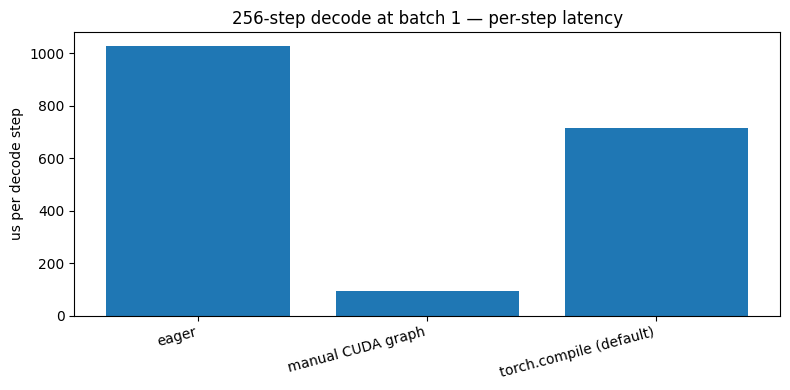

In [12]:
# DO NOT EDIT — the final benchmark. (GPU only.)
if DEVICE == "cuda":
    N_STEPS = 256

    def run_decode(step_fn, x0, n_steps=N_STEPS):
        x = x0
        for _ in range(n_steps):
            x = step_fn(x)
        return x

    variants = {"eager": decoder,
                "manual CUDA graph": make_graphed_callable(decoder, example)}
    try:
        dynamo.reset()
        variants["torch.compile (default)"] = torch.compile(decoder)
        variants["torch.compile (reduce-overhead)"] = torch.compile(
            decoder, mode="reduce-overhead")
    except Exception as e:
        print(f"torch.compile unavailable: {type(e).__name__}: {e}")

    times_step = {}
    for name, fn in variants.items():
        try:
            t = bench(lambda: run_decode(fn, example), n_warmup=3, n_iters=10)
            times_step[name] = t / N_STEPS
        except Exception as e:
            print(f"{name}: FAILED ({type(e).__name__}: {e}) "
                  f"— see Q3 on CUDA-graph constraints")

    base = times_step["eager"]
    print()
    for name, t in times_step.items():
        print(f"{name:34s} {t*1e6:8.1f} us/step   {base/t:5.2f}x vs eager")

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 4))
    names = list(times_step)
    ax.bar(names, [times_step[n] * 1e6 for n in names], color="tab:blue")
    ax.set_ylabel("us per decode step")
    ax.set_title(f"{N_STEPS}-step decode at batch 1 — per-step latency")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, "decode_step_latency.png"), dpi=130)
    plt.show()
else:
    print("SKIP — the benchmark needs a GPU.")

### Q1

`broken_decode_step` contains three constructs that prevent compiling it as one
graph: the `.item()`, the Python `if` on tensor data, and the `print`. For each
one: why can't dynamo trace through it, and what did you replace it with? Why is
`.item()` on the hot path *doubly* bad — what does it force the CPU to do that
the other two don't?

**Your answer:**

> Dynamo traces *tensor* operations into a graph; it breaks whenever the Python
> code needs a concrete, host-side value or has a side effect it can't express
> as a tensor op.
>
> - **`scale = h.abs().max().item()`** — `.item()` demands a real Python number
>   pulled out of GPU memory. Dynamo can't keep that symbolic, so it ends the
>   graph. **Replaced with** `scale = h.abs().max()`, kept as a 0-dim *tensor*
>   that flows through the graph.
> - **`if scale > 3.0:`** — a Python branch whose direction depends on runtime
>   tensor data dynamo doesn't know at trace time; it can't pick a side, so it
>   breaks (and would specialize/recompile per outcome). **Replaced with**
>   `torch.where(scale > 3.0, h / scale, h)` — both arms are computed on the GPU
>   and the condition stays a tensor, so there's nothing to branch on in Python.
> - **`print(...)`** — a Python side effect that forces the value to the host
>   and can't live in the graph. **Replaced with** nothing — logging has no
>   place on the hot path.
>
> **Why `.item()` is doubly bad:** the `if` and `print` only *break the graph*
> (lost fusion). `.item()` does that **and** forces a **host–device sync**: the
> CPU must issue a `cudaStreamSynchronize` and *block* until the GPU has produced
> the value. That serializes CPU and GPU — the CPU can't run ahead and queue the
> next step's kernels — so on a hot decode loop it doesn't just cost fusion, it
> destroys the CPU/GPU overlap that keeps the GPU fed. (This is exactly the
> per-step stall we removed in HW2.)

### Q2

In your Part 3 numbers, graph replay (manual or `reduce-overhead`) should beat
eager by the largest factor. Why does it help **small-batch decode**
specifically (think back to Part 1), and which constraints did you have to
respect to make capture and replay work (shapes, memory addresses, host syncs)?

**Your answer:**

> My numbers: eager **1029 µs/step**, **manual CUDA graph 92 µs/step (11.1×)**,
> `torch.compile (default)` 716 µs (1.4×). (`reduce-overhead` errored here — see
> Q3.)
>
> **Why it helps small-batch decode:** Part 1 measured per-launch overhead at
> **≈19 µs**, flat for any tensor up to a few million elements — i.e. small
> kernels are *free on the GPU but expensive to launch*. The TinyDecoder step is
> dozens of such small kernels (4 blocks × LayerNorm/Linear/GELU/Linear + adds)
> at batch 1, so its eager time is essentially `#kernels × launch_overhead`, paid
> by the CPU every step. The GPU is mostly idle between launches. A CUDA graph
> records that whole kernel sequence once and replays it with a **single**
> launch, so ~all the per-kernel CPU dispatch vanishes — hence the ~11× jump.
> (At large batch / big layers each kernel would be long enough to hide its own
> launch, and the win would shrink.)
>
> **Constraints I had to respect for capture + replay:**
> - **Fixed shapes/dtype** — the graph bakes in tensor sizes; a new shape needs
>   a new capture. Decode at batch 1, one token, is perfectly static.
> - **Fixed memory addresses** — replay re-runs the *same* pointers. So input
>   goes through a **static buffer** I `copy_` new data into, and output comes
>   back in a **static buffer** I must `clone()` before the next replay
>   overwrites it. (Skipping the `copy_` would keep replaying stale input; the
>   self-check catches that.)
> - **No host syncs / no allocation / no control flow** inside the captured
>   region — nothing that talks to the CPU or allocates fresh memory.
> - **Side-stream warmup before capture** — a few warmup iters on a separate
>   stream let cuBLAS pick kernels and allocate workspace, and capture refuses to
>   start on a stream with pending work.

### Q3

`torch.compile` is not free speed. Name two situations where compiling makes
things slower or simply doesn't help (think: compile latency vs short jobs,
recompiles from changing shapes, kernels that are already bandwidth-bound), and
say how you would *detect* each one with the tools from HW1–HW2 (roofline,
profiler traces).

**Your answer:**

> **1) Compile latency vs short jobs.** The first call to a compiled function
> pays seconds of Dynamo tracing + Inductor codegen (+ Triton autotuning). If
> the job only runs a handful of iterations, you never amortize that — the
> compiled run is *slower* end-to-end than eager.
> *Detect:* time with the HW1 `benchmark_fn` **including** the first call, or
> look at the profiler/trace — the first iteration is a giant outlier (compile)
> while later ones are fast. If `warmup_time + N·compiled` > `N·eager` for your
> real N, skip compile.
>
> **2) Recompiles from changing shapes.** Dynamo specializes on input shapes; if
> shapes vary (variable seq length, ragged batch) it **recompiles** for each new
> shape, and you pay the compile cost over and over — often a net loss.
> *Detect:* `TORCH_LOGS="recompiles"` (or `torch._dynamo` logs) reports each
> recompilation with its guard; in a profiler trace you'll see periodic
> multi-second compile spikes interleaved with execution instead of one upfront.
> Mark dynamic dims (`mark_dynamic`) or use static shapes/padding to fix it.
>
> **(Bonus) Already bandwidth-bound kernels.** Fusion's payoff is cutting HBM
> round-trips and launches; a kernel that's already saturating HBM (a single big
> elementwise/reduction) has little to gain.
> *Detect:* put it on the **HW1 roofline** — if the point already sits on the
> sloped memory ceiling (achieved GB/s ≈ peak), compile can't move it up; the
> profiler will show it's a single kernel already at peak bandwidth.
>
> *Footnote from this notebook:* `torch.compile(mode="reduce-overhead")` failed
> in the final benchmark with "accessing tensor output of CUDAGraphs that has
> been overwritten." That's the **static-buffer constraint** from Q2: the
> sequential decode feeds step *t*'s output in as step *t+1*'s input, but
> reduce-overhead's CUDA-graph reuses that output buffer, so the next replay
> clobbers it before it's read. My **manual** graph avoids it by `clone()`-ing
> the output each step — a concrete example that graph capture trades flexibility
> for speed.